# Introvert vs Extrovert Personality Prediction

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [23]:
DATA_PATH = "data/personality_dataset.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [24]:
print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())
print("Missing values:")
print(df.isna().sum())
print("Target distribution:")
print(df["Personality"].value_counts())

Dataset shape: (2900, 8)
Columns:
['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency', 'Personality']
Missing values:
Time_spent_Alone             63
Stage_fear                   73
Social_event_attendance      62
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64
Target distribution:
Personality
Extrovert    1491
Introvert    1409
Name: count, dtype: int64


In [25]:
df_clean = df.copy()

TARGET = "Personality"
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
Categorical features: ['Stage_fear', 'Drained_after_socializing']


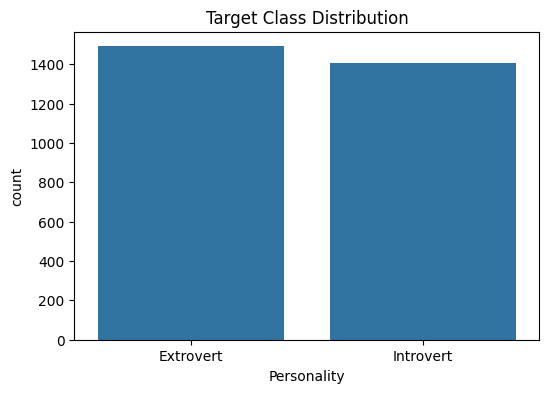

In [26]:
# Target balance
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x="Personality")
plt.title("Target Class Distribution")
plt.show()